# BDT Score 2D Scatter — HESE data

Scatter plot of `bdt_scores1` vs `bdt_scores2` for the HESE pass2 v3 data, with optional `reco_length` cut.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [20]:
THIJS_PARQUET = (
    "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/datasets/"
    "flavor_globalfit/hese/combined_with_bdt/data_HESE_pass2_v3/"
    "mcd-simpletopology_flux-hese_feat-11features_plus_rloglmilli_econf_evtgen/"
    "dataset_data_HESE_pass2_v3.parquet"
)

df = pd.read_parquet(THIJS_PARQUET)
print(f"Total events: {len(df)}")
print(f"reco_length range: [{df['reco_length'].min():.1f}, {df['reco_length'].max():.1f}] m")
df[["bdt_scores1", "bdt_scores2", "reco_length"]].describe()

Total events: 188
reco_length range: [1.8, 1000.0] m


,bdt_scores1,bdt_scores2,reco_length
count,188.000000,188.000000,188.000000
mean,0.365367,0.290750,168.075878
std,0.422191,0.290905,217.605182
min,0.000191,0.004052,1.848466
25%,0.005333,0.030858,7.567125
50%,0.082185,0.146854,62.951621
75%,0.892136,0.507127,253.543243
max,0.999278,0.991212,999.999959


In [21]:
import matplotlib.colors as mcolors

# Selection box boundaries
BDT1_CUT = 0.333333
BDT2_CUT = 0.366667

# Default cut values
RECO_LENGTH_CUT = 10.0    # metres
RECO_ENERGY_CUT = 60e3   # GeV


def plot_bdt_scatter(
    df: pd.DataFrame,
    reco_length_cut: float | None = None,
    reco_energy_cut: float | None = None,
    ax: plt.Axes | None = None,
) -> plt.Axes:
    """2-D scatter of bdt_scores1 vs bdt_scores2.

    Parameters
    ----------
    df : full data frame
    reco_length_cut : if not None, keep only events with reco_length > this value
    reco_energy_cut : if not None, keep only events with reco_energy > this value
    ax : existing axes to draw on; creates a new figure if None
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))
    else:
        fig = ax.figure

    mask = np.ones(len(df), dtype=bool)
    if reco_length_cut is not None:
        mask &= df["reco_length"].values > reco_length_cut
    if reco_energy_cut is not None:
        mask &= df["reco_energy"].values > reco_energy_cut

    sel = df[mask]
    n_sel = mask.sum()
    n_tot = len(df)

    cut_parts = []
    if reco_length_cut is not None:
        cut_parts.append(f"reco_length > {reco_length_cut} m")
    if reco_energy_cut is not None:
        cut_parts.append(f"reco_energy > {reco_energy_cut/1e3:.0f} TeV")
    title_suffix = (
        ",  ".join(cut_parts) + f"  ({n_sel}/{n_tot})"
        if cut_parts else f"no cuts  ({n_tot} events)"
    )

    ax.scatter(
        sel["bdt_scores1"],
        sel["bdt_scores2"],
        s=30,
        alpha=0.8,
        edgecolors="none",
    )

    # Selection box: bdt1 > BDT1_CUT, bdt2 > BDT2_CUT
    rect = mpatches.FancyBboxPatch(
        (BDT1_CUT, BDT2_CUT), 1.0 - BDT1_CUT, 1.0 - BDT2_CUT,
        boxstyle="square,pad=0",
        linewidth=2,
        edgecolor="red",
        facecolor="none",
        zorder=5,
    )
    ax.add_patch(rect)

    in_box = ((sel["bdt_scores1"] > BDT1_CUT) & (sel["bdt_scores2"] > BDT2_CUT)).sum()
    ax.text(
        BDT1_CUT + 0.01, BDT2_CUT + 0.01,
        f"{in_box} events",
        color="red", fontsize=9, va="bottom", ha="left",
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("BDT score 1", fontsize=12)
    ax.set_ylabel("BDT score 2", fontsize=12)
    ax.set_title(f"HESE data\n{title_suffix}", fontsize=10)
    ax.grid(True, alpha=0.3)

    return ax

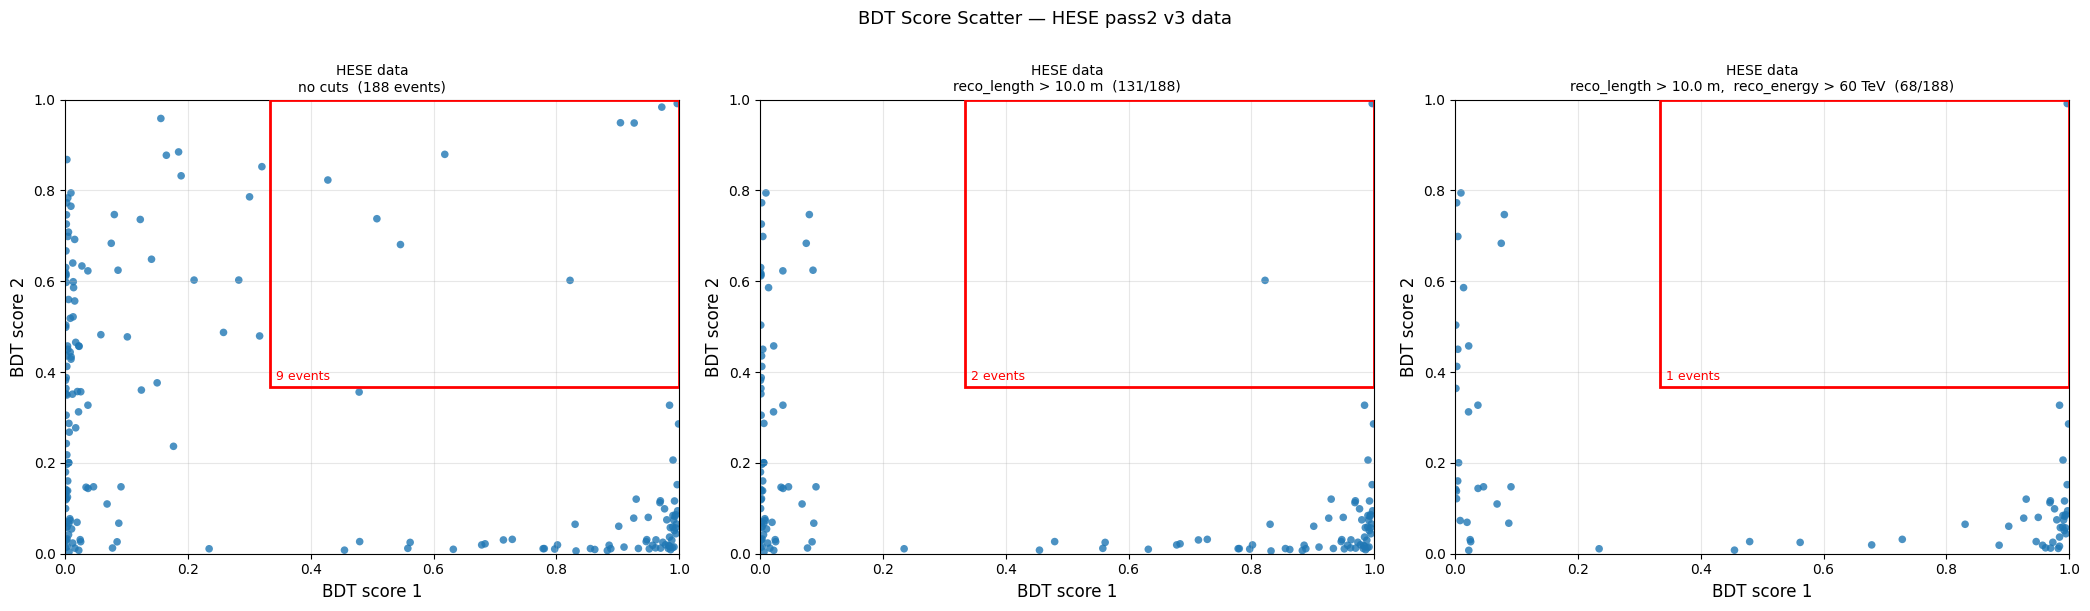

Saved to /data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/step2_hese_flavor/bdt_scatter_data


In [22]:
import os

OUTDIR = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/step2_hese_flavor/bdt_scatter_data"
os.makedirs(OUTDIR, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

plot_bdt_scatter(df, ax=axes[0])
plot_bdt_scatter(df, reco_length_cut=RECO_LENGTH_CUT, ax=axes[1])
plot_bdt_scatter(df, reco_length_cut=RECO_LENGTH_CUT, reco_energy_cut=RECO_ENERGY_CUT, ax=axes[2])

fig.suptitle("BDT Score Scatter — HESE pass2 v3 data", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "bdt_scatter.png"), dpi=150, bbox_inches="tight")
plt.savefig(os.path.join(OUTDIR, "bdt_scatter.pdf"), bbox_inches="tight")
plt.show()
print(f"Saved to {OUTDIR}")